<a href="https://colab.research.google.com/github/diyapatel1225-cmyk/Tomato_Leaf_Disease_Detection-Severity_Assessment/blob/main/Tomato_Disease_Detection_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tomato Leaf Disease Detection + Severity Assessment — DenseNet121 Variant

**Project:** AI-Based Tomato Plant Disease Detection and Severity Assessment Using Deep Learning

This is the **DenseNet121 counterpart** of your MobileNetV2 and EfficientNetB0 notebooks. Data loading,
severity labeling, split, augmentation, training schedule, and evaluation are all kept **identical** —
only the backbone (and the few lines that depend on it: `preprocess_input` and the Grad-CAM layer name)
change. This keeps the three-way backbone comparison in your paper fair: any accuracy difference you see
is attributable to the architecture, not a different experimental setup.

DenseNet121 completes a design-philosophy spread worth naming in your paper: MobileNetV2 (depthwise-
separable, mobile-first), EfficientNetB0 (compound-scaled), DenseNet121 (dense feature reuse — every
layer receives the feature maps of all preceding layers within a block). That dense connectivity is
historically strong at fine-grained texture tasks, which is worth highlighting given severity assessment
(judging *how much* of a leaf is diseased) is fundamentally a texture/color-gradation problem.

## Step 1: Setup & Imports

Same as before — no changes here.

In [ ]:
!pip install -q tensorflow opencv-python scikit-learn seaborn kaggle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os, shutil, random, zipfile, json, time
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Get the Dataset

Same dataset, same path — edit `ZIP_PATH` if needed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/Tomato_Project/tomato_leaves.zip"

EXTRACT_PATH = "/content/data"
os.makedirs(EXTRACT_PATH, exist_ok=True)

if not os.path.exists(os.path.join(EXTRACT_PATH, "tomato_leaves")):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extracted dataset to", EXTRACT_PATH)
else:
    print("Dataset already extracted, skipping unzip.")

DATA_DIR = "/content/data/tomato/train"
print("Classes found:", os.listdir(DATA_DIR))

Mounted at /content/drive
Extracted dataset to /content/data
Classes found: ['Tomato___Septoria_leaf_spot', 'Tomato___healthy', 'Tomato___Tomato_mosaic_virus', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Leaf_Mold', 'Tomato___Target_Spot', 'Tomato___Bacterial_spot']


## Step 3: Auto-generate Severity Labels

Identical rule-based HSV severity estimator as your other two notebooks — unchanged so severity labels
don't become a second variable in the comparison.

In [ ]:
def estimate_severity(image_path):
    """Returns severity label: 0=Healthy, 1=Mild, 2=Moderate, 3=Severe"""
    img = cv2.imread(image_path)
    if img is None:
        return 0
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    green_lower = np.array([25, 40, 40])
    green_upper = np.array([90, 255, 255])
    green_mask = cv2.inRange(hsv, green_lower, green_upper)

    disease_lower = np.array([0, 40, 20])
    disease_upper = np.array([30, 255, 200])
    disease_mask = cv2.inRange(hsv, disease_lower, disease_upper)

    total_leaf_pixels = cv2.countNonZero(green_mask) + cv2.countNonZero(disease_mask)
    if total_leaf_pixels == 0:
        return 0

    diseased_ratio = cv2.countNonZero(disease_mask) / total_leaf_pixels

    if diseased_ratio < 0.05:
        return 0
    elif diseased_ratio < 0.15:
        return 1
    elif diseased_ratio < 0.35:
        return 2
    else:
        return 3

SEVERITY_NAMES = ["Healthy", "Mild", "Moderate", "Severe"]

sample_class = os.listdir(DATA_DIR)[0]
sample_folder = os.path.join(DATA_DIR, sample_class)
for _ in range(10):
    sample_img = os.path.join(sample_folder, random.choice(os.listdir(sample_folder)))
    print(sample_img, ":", SEVERITY_NAMES[estimate_severity(sample_img)])

/content/data/tomato/train/Tomato___Septoria_leaf_spot/fcd686b5-7726-4faf-89b5-13ae16e5244f___JR_Sept.L.S 2636.JPG : Mild
/content/data/tomato/train/Tomato___Septoria_leaf_spot/a63b93a4-167f-4544-9a84-1e0d05bf35f6___Matt.S_CG 7623.JPG : Moderate
/content/data/tomato/train/Tomato___Septoria_leaf_spot/a7c9d081-6e31-4344-bfe4-6184a6b16df8___JR_Sept.L.S 2588.JPG : Mild
/content/data/tomato/train/Tomato___Septoria_leaf_spot/c54cd0ca-8eaa-4b3d-88bd-5f4554c82b6e___Matt.S_CG 6360.JPG : Severe
/content/data/tomato/train/Tomato___Septoria_leaf_spot/b0e900f0-d8b8-4efe-a447-4cd4340417d3___Matt.S_CG 7582.JPG : Moderate
/content/data/tomato/train/Tomato___Septoria_leaf_spot/bcb7e120-e71a-4fd2-9e89-91631c0b5dcd___Keller.St_CG 2044.JPG : Mild
/content/data/tomato/train/Tomato___Septoria_leaf_spot/baeeb93d-df9f-489a-a019-5adc8cf361a3___Matt.S_CG 7450.JPG : Healthy
/content/data/tomato/train/Tomato___Septoria_leaf_spot/06225525-413e-411b-a503-85e8dc6050a8___JR_Sept.L.S 8351.JPG : Mild
/content/data/toma

## Step 4: Build a Labeled DataFrame

Same as before.

In [ ]:
records = []
for class_name in os.listdir(DATA_DIR):
    class_folder = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_folder):
        continue
    for fname in os.listdir(class_folder):
        fpath = os.path.join(class_folder, fname)
        severity = 0 if "healthy" in class_name.lower() else estimate_severity(fpath)
        records.append({"filepath": fpath, "disease": class_name, "severity": severity})

df = pd.DataFrame(records)
print("Total images:", len(df))
print(df['disease'].value_counts())
print(df['severity'].value_counts())
df.head()

Total images: 10000
disease
Tomato___Septoria_leaf_spot                      1000
Tomato___healthy                                 1000
Tomato___Tomato_mosaic_virus                     1000
Tomato___Early_blight                            1000
Tomato___Late_blight                             1000
Tomato___Spider_mites Two-spotted_spider_mite    1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus           1000
Tomato___Leaf_Mold                               1000
Tomato___Target_Spot                             1000
Tomato___Bacterial_spot                          1000
Name: count, dtype: int64
severity
0    4972
1    2591
2    1283
3    1154
Name: count, dtype: int64


,filepath,disease,severity
0,/content/data/tomato/train/Tomato___Septoria_l...,Tomato___Septoria_leaf_spot,1
1,/content/data/tomato/train/Tomato___Septoria_l...,Tomato___Septoria_leaf_spot,2
2,/content/data/tomato/train/Tomato___Septoria_l...,Tomato___Septoria_leaf_spot,0
3,/content/data/tomato/train/Tomato___Septoria_l...,Tomato___Septoria_leaf_spot,0
4,/content/data/tomato/train/Tomato___Septoria_l...,Tomato___Septoria_leaf_spot,1


In [ ]:
df.to_csv("/content/labeled_dataset_densenet.csv", index=False)
print("Saved labeled_dataset_densenet.csv with", len(df), "rows")

Saved labeled_dataset_densenet.csv with 10000 rows


## Step 5: Encode Labels & Split Data

**Critical for a fair comparison:** `random_state=42` is identical to the other two notebooks, so this
produces the exact same train/val/test split (same images in each set). Don't change this seed.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

disease_encoder = LabelEncoder()
df['disease_label'] = disease_encoder.fit_transform(df['disease'])
NUM_DISEASE_CLASSES = len(disease_encoder.classes_)
NUM_SEVERITY_CLASSES = 4

print("Disease classes:", list(disease_encoder.classes_))

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['disease_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['disease_label'], random_state=42)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Disease classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Train: 7000 Val: 1500 Test: 1500


## Step 6: Preprocessing & Augmentation Pipeline

**Only change from the other notebooks:** the preprocessing function is now
`keras.applications.densenet.preprocess_input` (DenseNet expects a different pixel scaling than
MobileNetV2 or EfficientNet). Augmentation logic and image size (224x224) are unchanged.

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess(filepath, disease_label, severity_label, augment=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.rot90(img, k=random.randint(0, 3))

    img = keras.applications.densenet.preprocess_input(img)   # <-- CHANGED for DenseNet121
    return img, {"disease_output": disease_label, "severity_output": severity_label}

def make_dataset(dataframe, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['filepath'].values,
        dataframe['disease_label'].values,
        dataframe['severity'].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.map(lambda f, d, s: load_and_preprocess(f, d, s, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds   = make_dataset(val_df, augment=False, shuffle=False)
test_ds  = make_dataset(test_df, augment=False, shuffle=False)

print("Datasets ready.")

Datasets ready.


## Step 7: Build the DenseNet121 Multi-Task Model

Same architecture shape as before, only the backbone changed:

```
Input Image (224x224x3)
        |
   DenseNet121 (pretrained on ImageNet, dense feature-reuse blocks)
        |
   Global Average Pooling
        |
   Shared Dense layer
      /        \
Disease Head   Severity Head
 (10 classes)   (4 classes)
```

All head layers (`GlobalAveragePooling2D`, `Dropout`, `shared_dense`, disease/severity branches) use the
**exact same layer sizes and names** as your other two notebooks, so any comparison/Grad-CAM code you
reuse doesn't need restructuring.

Note: DenseNet121 is deeper (121 layers) but more parameter-efficient than a classic ResNet of similar
depth, because of its feature-reuse design — worth mentioning in your params-vs-accuracy discussion.

In [ ]:
base_model = keras.applications.DenseNet121(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Phase A: freeze the base

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
shared = layers.Dense(256, activation='relu', name="shared_dense")(x)
shared = layers.Dropout(0.2)(shared)

disease_branch = layers.Dense(128, activation='relu')(shared)
disease_output = layers.Dense(NUM_DISEASE_CLASSES, activation='softmax', name="disease_output")(disease_branch)

severity_branch = layers.Dense(64, activation='relu')(shared)
severity_output = layers.Dense(NUM_SEVERITY_CLASSES, activation='softmax', name="severity_output")(severity_branch)

model = keras.Model(inputs=inputs, outputs=[disease_output, severity_output])

model.summary()

total_params = model.count_params()
print("\nTotal parameters:", f"{total_params:,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_1[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 256)       │    262,400 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_output      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 4)         │        260 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,350,798 (28.04 MB)

 Trainable params: 313,294 (1.20 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


Total parameters: 7,350,798


## Step 8: Compile the Model

Same optimizer, loss, and loss_weights as the other two notebooks — keeping this identical isolates the backbone as the only variable.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "severity_output": "sparse_categorical_crossentropy"
    },
    loss_weights={"disease_output": 1.0, "severity_output": 0.7},
    metrics={
        "disease_output": "accuracy",
        "severity_output": "accuracy"
    }
)
print("Model compiled.")

Model compiled.


## Step 9: Phase A Training — Train the New Head Only

Same callbacks, same epoch budget (15). Timing this phase (and Phase B) gives you the training-speed
numbers for the comparison table — DenseNet121's dense connections mean more tensor concatenation
overhead per step than either MobileNetV2 or EfficientNetB0, so expect this to be your slowest backbone
per epoch even though its parameter count is moderate.

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('/content/best_model_phaseA_densenet.keras', monitor='val_loss', save_best_only=True)
]

t0 = time.time()
history_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)
phaseA_time = time.time() - t0
print(f"\nPhase A training time: {phaseA_time:.1f} sec")

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 319ms/step - disease_output_accuracy: 0.5617 - disease_output_loss: 1.2474 - loss: 1.9323 - severity_output_accuracy: 0.5711 - severity_output_loss: 0.9774 - val_disease_output_accuracy: 0.7640 - val_disease_output_loss: 0.6921 - val_loss: 1.2350 - val_severity_output_accuracy: 0.6560 - val_severity_output_loss: 0.7750
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - disease_output_accuracy: 0.7447 - disease_output_loss: 0.7422 - loss: 1.2921 - severity_output_accuracy: 0.6613 - severity_output_loss: 0.7856 - val_disease_output_accuracy: 0.7733 - val_disease_output_loss: 0.6530 - val_loss: 1.1404 - val_severity_output_accuracy: 0.7040 - val_severity_output_loss: 0.6953
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - disease_output_accuracy: 0.7791 - disease_output_loss: 0.6318 - loss: 1.1418 - severity_output_accuracy: 0.6776 - severity_output_loss: 0.7298 - val_disease_output_accuracy: 0.8240 - val_disease_output_loss: 0.46

## Step 10: Phase B — Fine-Tune DenseNet121

Same fine-tuning strategy: unfreeze the last 30 layers, drop the learning rate to 1e-5, continue training.
Kept identical to the other two notebooks' fine-tuning depth so this stays a pure backbone comparison.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "severity_output": "sparse_categorical_crossentropy"
    },
    loss_weights={"disease_output": 1.0, "severity_output": 0.7},
    metrics={
        "disease_output": "accuracy",
        "severity_output": "accuracy"
    }
)

callbacks_b = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('/content/best_model_finetuned_densenet.keras', monitor='val_loss', save_best_only=True)
]

t0 = time.time()
history_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_b
)
phaseB_time = time.time() - t0
print(f"\nPhase B training time: {phaseB_time:.1f} sec")

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 317ms/step - disease_output_accuracy: 0.4630 - disease_output_loss: 3.7799 - loss: 5.7961 - severity_output_accuracy: 0.3236 - severity_output_loss: 2.8763 - val_disease_output_accuracy: 0.6753 - val_disease_output_loss: 1.2868 - val_loss: 2.2791 - val_severity_output_accuracy: 0.5107 - val_severity_output_loss: 1.4166
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 133ms/step - disease_output_accuracy: 0.6480 - disease_output_loss: 1.6815 - loss: 2.8186 - severity_output_accuracy: 0.4944 - severity_output_loss: 1.6244 - val_disease_output_accuracy: 0.7487 - val_disease_output_loss: 1.0011 - val_loss: 1.7644 - val_severity_output_accuracy: 0.6053 - val_severity_output_loss: 1.0888
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - disease_output_accuracy: 0.7546 - disease_output_loss: 0.9808 - loss: 1.7626 - severity_output_accuracy: 0.5989 - severity_output_loss: 1.1166 - val_disease_output_accuracy: 0.7973 - val_disease_output_loss: 0.72

## Step 10b: Check the Train/Val Gap (Overfitting Check)

Worth running explicitly this time — you flagged overfitting as a concern with EfficientNetB0 too. Prints
the final train vs. val accuracy for both tasks so you can see the gap directly, rather than eyeballing
the curve plot.

In [ ]:
final_train_disease = history_b.history['disease_output_accuracy'][-1]
final_val_disease = history_b.history['val_disease_output_accuracy'][-1]
final_train_severity = history_b.history['severity_output_accuracy'][-1]
final_val_severity = history_b.history['val_severity_output_accuracy'][-1]

print(f"Disease  -> train: {final_train_disease:.4f}   val: {final_val_disease:.4f}   gap: {final_train_disease - final_val_disease:.4f}")
print(f"Severity -> train: {final_train_severity:.4f}   val: {final_val_severity:.4f}   gap: {final_train_severity - final_val_severity:.4f}")
print("\nCompare these gaps against MobileNetV2 (train 95.7% / test 84%, ~12pt gap) and your EfficientNetB0 numbers to judge whether DenseNet121 is generalizing better or just fitting harder.")

Disease  -> train: 0.8913   val: 0.8800   gap: 0.0113
Severity -> train: 0.7349   val: 0.7493   gap: -0.0145

Compare these gaps against MobileNetV2 (train 95.7% / test 84%, ~12pt gap) and your EfficientNetB0 numbers to judge whether DenseNet121 is generalizing better or just fitting harder.


## Step 11: Plot Training Curves

Same plotting function as before.

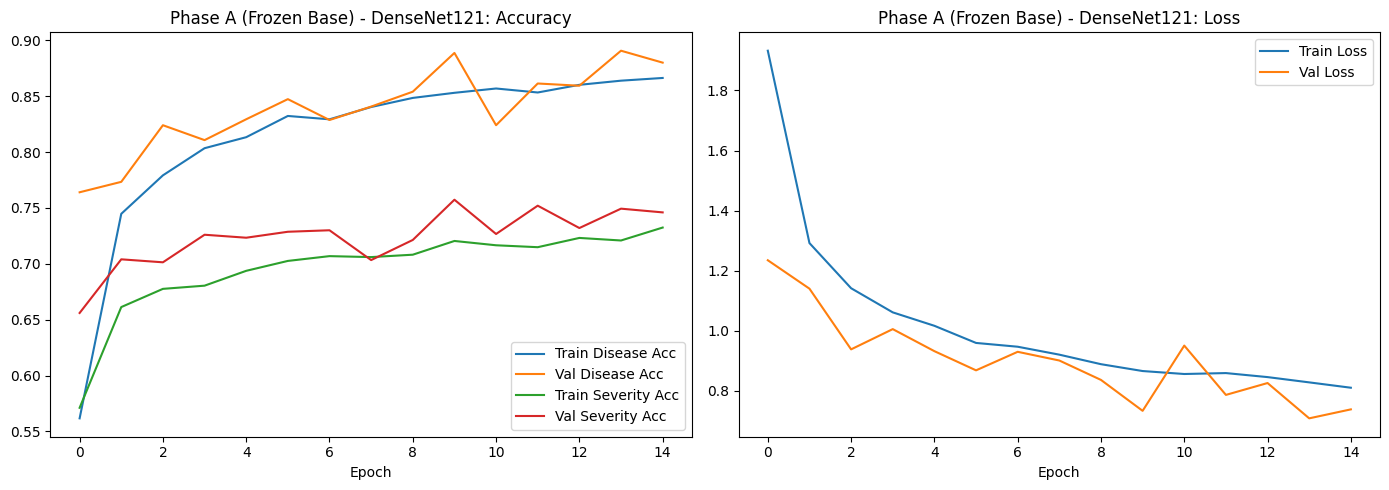

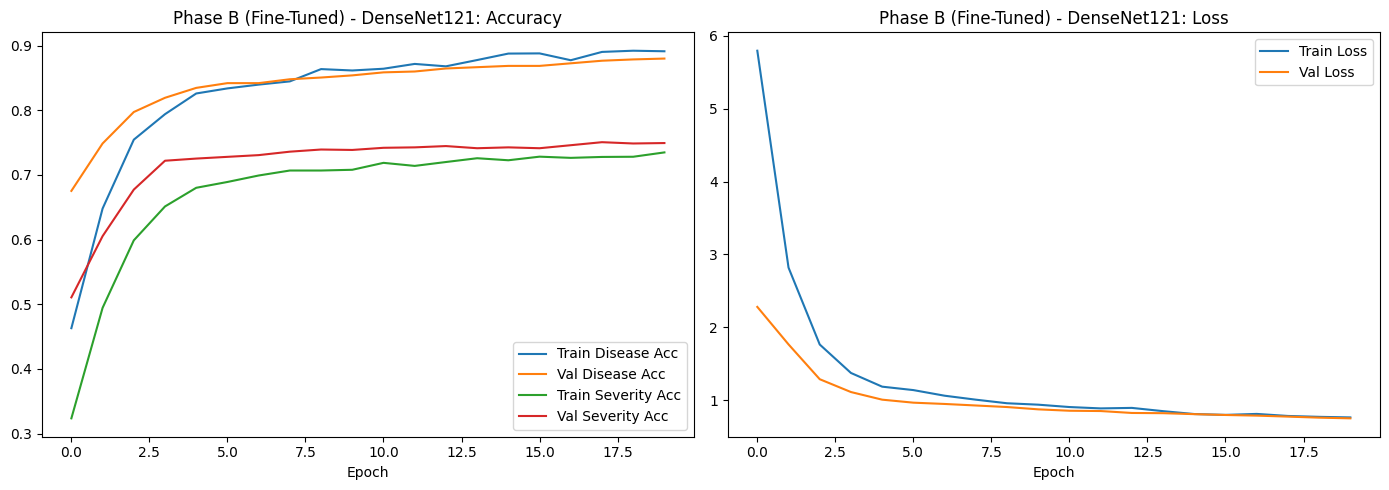

In [ ]:
def plot_history(history, phase_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['disease_output_accuracy'], label='Train Disease Acc')
    axes[0].plot(history.history['val_disease_output_accuracy'], label='Val Disease Acc')
    axes[0].plot(history.history['severity_output_accuracy'], label='Train Severity Acc')
    axes[0].plot(history.history['val_severity_output_accuracy'], label='Val Severity Acc')
    axes[0].set_title(f'{phase_name}: Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{phase_name}: Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_a, "Phase A (Frozen Base) - DenseNet121")
plot_history(history_b, "Phase B (Fine-Tuned) - DenseNet121")

## Step 12: Final Evaluation on Test Set

Same test set (identical split, same `random_state=42`) as the other two runs, so these numbers are
directly comparable side-by-side in your results table.

In [ ]:
y_disease_true, y_severity_true = [], []
y_disease_pred, y_severity_pred = [], []

t0 = time.time()
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    disease_preds = np.argmax(preds[0], axis=1)
    severity_preds = np.argmax(preds[1], axis=1)

    y_disease_true.extend(labels['disease_output'].numpy())
    y_severity_true.extend(labels['severity_output'].numpy())
    y_disease_pred.extend(disease_preds)
    y_severity_pred.extend(severity_preds)
inference_time = time.time() - t0
print(f"Inference time on test set ({len(y_disease_true)} images): {inference_time:.2f} sec "
      f"({(inference_time/len(y_disease_true))*1000:.2f} ms/image)")

print("\n=== DISEASE CLASSIFICATION REPORT (DenseNet121) ===")
print(classification_report(y_disease_true, y_disease_pred, target_names=disease_encoder.classes_))

print("=== SEVERITY CLASSIFICATION REPORT (DenseNet121) ===")
print(classification_report(y_severity_true, y_severity_pred, target_names=SEVERITY_NAMES))

Inference time on test set (1500 images): 42.44 sec (28.29 ms/image)

=== DISEASE CLASSIFICATION REPORT (DenseNet121) ===
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.79      0.87       150
                        Tomato___Early_blight       0.82      0.90      0.86       150
                         Tomato___Late_blight       0.85      0.97      0.91       150
                           Tomato___Leaf_Mold       0.86      0.97      0.91       150
                  Tomato___Septoria_leaf_spot       0.84      0.91      0.87       150
Tomato___Spider_mites Two-spotted_spider_mite       0.95      0.54      0.69       150
                         Tomato___Target_Spot       0.88      0.75      0.81       150
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.96      0.99      0.98       150
                 Tomato___Tomato_mosaic_virus       0.83      0.99      0.90       150
       

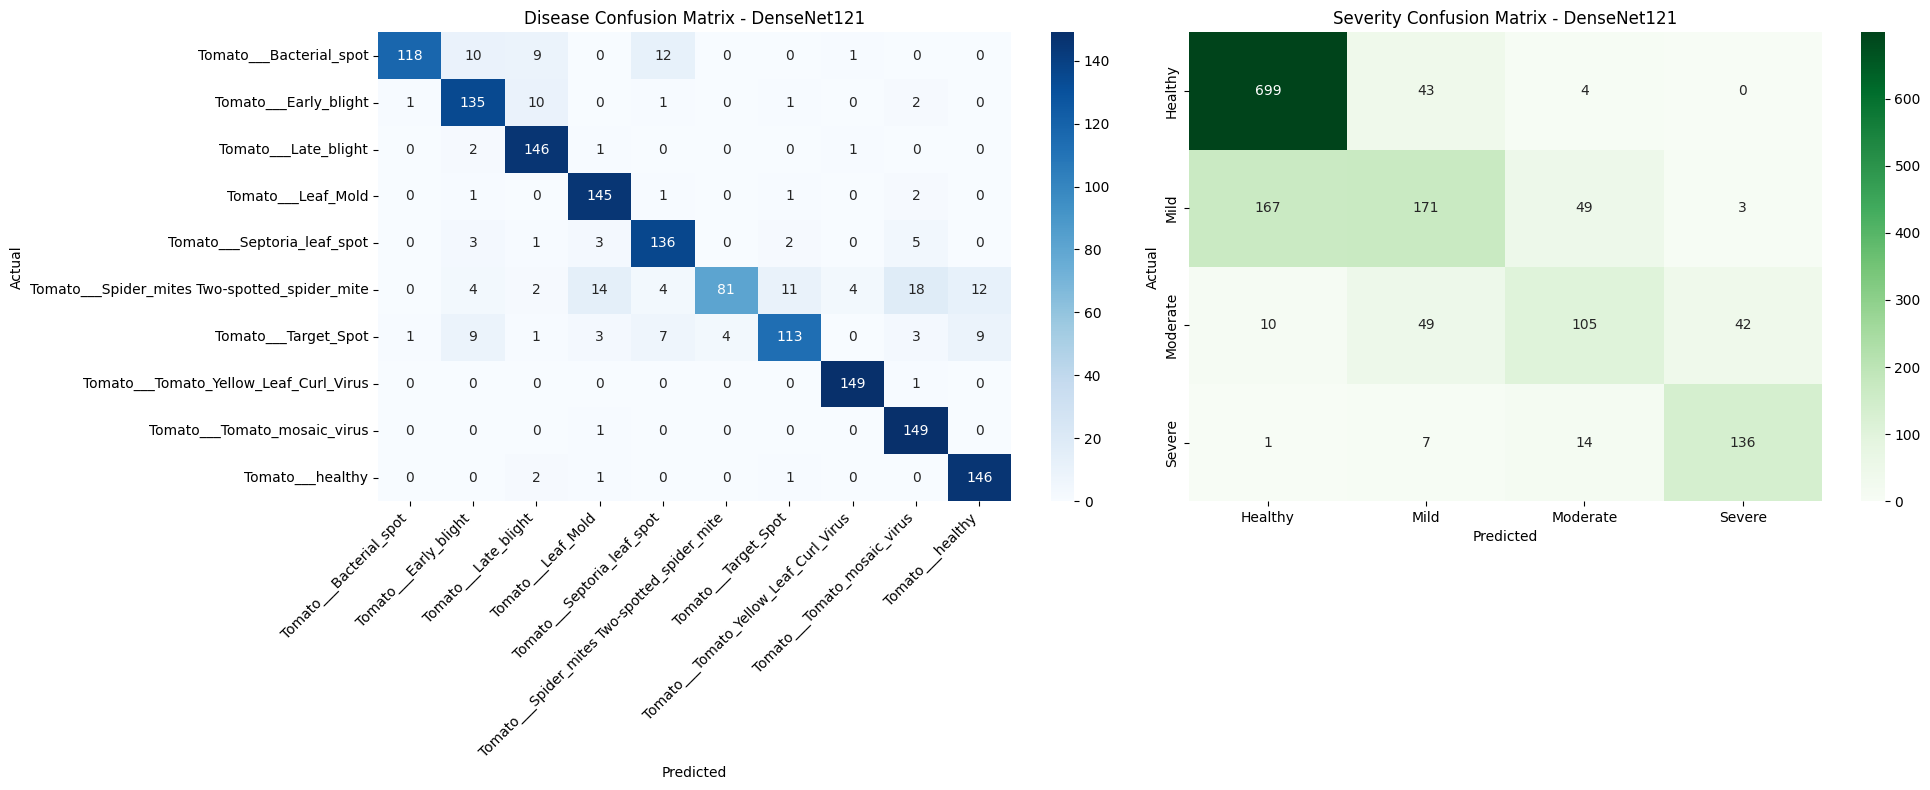

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_disease = confusion_matrix(y_disease_true, y_disease_pred)
sns.heatmap(cm_disease, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_encoder.classes_, yticklabels=disease_encoder.classes_, ax=axes[0])
axes[0].set_title('Disease Confusion Matrix - DenseNet121')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

cm_severity = confusion_matrix(y_severity_true, y_severity_pred)
sns.heatmap(cm_severity, annot=True, fmt='d', cmap='Greens',
            xticklabels=SEVERITY_NAMES, yticklabels=SEVERITY_NAMES, ax=axes[1])
axes[1].set_title('Severity Confusion Matrix - DenseNet121')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 13: Grad-CAM — Explainability

**Only change from the other notebooks:** `last_conv_layer_name` is now `"relu"` — that's the name Keras
gives DenseNet121's final activation layer (after the last batch norm, before global pooling). This
differs from MobileNetV2's `"Conv_1"` and EfficientNetB0's `"top_conv"` because DenseNet's final block
structure is different. If this name errors on your TF version, run `base_model.summary()` and check the
last few layer names — look for the last `Activation`/`ReLU` layer before the model ends.

Actual disease: Tomato___Late_blight


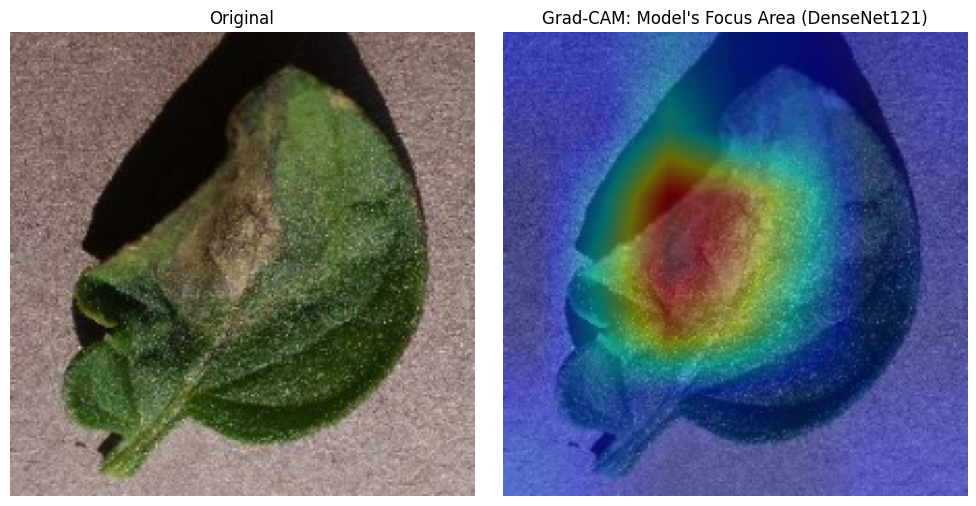

In [ ]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="relu", pred_index=None):
    conv_layer = base_model.get_layer(last_conv_layer_name)
    grad_model = keras.Model(inputs=base_model.input, outputs=[conv_layer.output, base_model.output])

    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(img_array)

        x = model.get_layer('global_average_pooling2d')(base_output)
        x = model.get_layer('dropout')(x)
        shared = model.get_layer('shared_dense')(x)
        shared = model.get_layer('dropout_1')(shared)
        disease_branch = model.get_layer('dense')(shared)
        disease_preds = model.get_layer('disease_output')(disease_branch)

        if pred_index is None:
            pred_index = tf.argmax(disease_preds[0])
        class_channel = disease_preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, model, base_model, last_conv_layer_name="relu", alpha=0.4):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_array = keras.applications.densenet.preprocess_input(np.expand_dims(img.numpy(), axis=0))

    heatmap = make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = img.numpy().astype('uint8')
    superimposed = cv2.addWeighted(original, 1 - alpha, heatmap_colored, alpha, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Grad-CAM: Model's Focus Area (DenseNet121)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

sample_path = test_df.iloc[0]['filepath']
print("Actual disease:", test_df.iloc[0]['disease'])
display_gradcam(sample_path, model, base_model)

## Step 14: Save & Export for Deployment

Same two export formats as before, with `_densenet` suffixes so they don't overwrite your other models.

In [ ]:
model.save('/content/tomato_disease_severity_model_densenet.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('/content/tomato_model_densenet.tflite', 'wb') as f:
    f.write(tflite_model)

print("Saved: tomato_disease_severity_model_densenet.keras and tomato_model_densenet.tflite")

import os as _os
tflite_size_kb = _os.path.getsize('/content/tomato_model_densenet.tflite') / 1024
print(f"TFLite model size: {tflite_size_kb:.1f} KB")

label_map = {
    "disease_classes": list(disease_encoder.classes_),
    "severity_classes": SEVERITY_NAMES
}
with open('/content/label_map_densenet.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print("Saved label_map_densenet.json")

Saved artifact at '/tmp/tmpg5wvc8tt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  List[TensorSpec(shape=(None, 10), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)]
Captures:
  138510079755664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079757008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079756624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079755472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079756240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079757584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079757200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079757776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079756816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138510079758352

## Step 15: (Optional) Download Your Trained Files

In [ ]:
from google.colab import files
files.download('/content/tomato_disease_severity_model_densenet.keras')
files.download('/content/tomato_model_densenet.tflite')
files.download('/content/label_map_densenet.json')

## Step 16: Build the Comparison Table Row

Same format as your MobileNetV2 and EfficientNetB0 rows — append this to the same comparison table for
your paper's results section. Includes the overfitting-gap columns from Step 10b so all three backbones'
generalization behavior is visible side by side.

In [ ]:
comparison_row_densenet = {
    "Backbone": "DenseNet121",
    "Total Params": f"{model.count_params():,}",
    "TFLite Size (KB)": round(tflite_size_kb, 1),
    "Phase A Time (s)": round(phaseA_time, 1),
    "Phase B Time (s)": round(phaseB_time, 1),
    "Inference (ms/img)": round((inference_time/len(y_disease_true))*1000, 2),
    "Disease Test Accuracy": round(
        classification_report(y_disease_true, y_disease_pred, target_names=disease_encoder.classes_, output_dict=True)['accuracy'], 4),
    "Severity Test Accuracy": round(
        classification_report(y_severity_true, y_severity_pred, target_names=SEVERITY_NAMES, output_dict=True)['accuracy'], 4),
    "Disease Train/Val Gap": round(final_train_disease - final_val_disease, 4),
    "Severity Train/Val Gap": round(final_train_severity - final_val_severity, 4),
}

comparison_df = pd.DataFrame([comparison_row_densenet])
print(comparison_df.to_string(index=False))
comparison_df.to_csv('/content/comparison_densenet.csv', index=False)
print("\nSaved comparison_densenet.csv — merge this with the MobileNetV2 and EfficientNetB0 rows for your paper's final table.")

   Backbone Total Params  TFLite Size (KB)  Phase A Time (s)  Phase B Time (s)  Inference (ms/img)  Disease Test Accuracy  Severity Test Accuracy  Disease Train/Val Gap  Severity Train/Val Gap
DenseNet121    7,350,798            7553.9             561.5             699.7               28.29                 0.8787                  0.7407                 0.0113                 -0.0145

Saved comparison_densenet.csv — merge this with the MobileNetV2 and EfficientNetB0 rows for your paper's final table.
